In [1]:
import hoda
import tensorly as tl
import mne

mne.set_log_level('ERROR')
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300, LeftRightImagery
from moabb.datasets import *
from mne.decoding import Scaler

#paradigm = P300(resample=64)
#dataset = Zhou2016()

paradigm = LeftRightImagery(resample=None)
dataset= BNCI2014_004()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)

session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]



To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [3]:
meta

,subject,session,run
0,1,0train,0
1,1,0train,0
2,1,0train,0
3,1,0train,0
4,1,0train,0
...,...,...,...
115,1,0train,0
116,1,0train,0
117,1,0train,0
118,1,0train,0


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
import numpy as np
from sklearn.model_selection import train_test_split
from hoda.tensorize import stf_tensor

X = epochs.get_data()
X = stf_tensor(X, sfreq=epochs.info['sfreq'])
X = tl.tensor(X)
y = labels

print(X.shape)
print(X.dtype)
print(X.device)

(120, 3, 23, 112)
float32
<CUDA Device 0>


In [7]:
from hoda.hoda import BTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter


bttda = BTTDA(
    ranks=[1]*8,
    hoda_params=dict(
        max_iter=256,
        tol=1e-12,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=True,
        extra_train_info=False,
        verbose=True,
        forward=False,
        random_state=42,
       
    ),
    verbose=True,
    extra_train_info=True,
)
#%env PYTHONWARNINGS=ignore
%time bttda.fit(X,y)

Fitting block 1/8...


  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

Fitting block 2/8...


  0%|          | 0/256 [00:00<?, ?it/s]

...

Fitting block 8/8...


  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

CPU times: user 29.3 s, sys: 104 ms, total: 29.4 s
Wall time: 29.5 s


BTTDA(extra_train_info=True,
      hoda_params={'extra_train_info': False, 'forward': False,
                   'init': 'random', 'max_iter': 256, 'obj': 'tr',
                   'random_state': 42, 'rank': 1, 'shrinkage': 'lw',
                   'solver': 'lanczos', 'taper': True, 'toeplitz': None,
                   'tol': 1e-12, 'verbose': True},
      ranks=[1, 1, 1, 1, 1, 1, 1, 1], verbose=True)

In [9]:
import pandas as pd
df = pd.DataFrame(bttda.train_info_)
df

,block,rank,F_tr,F_rt,mse
0,1,"(1, 1, 1)",0.050557,0.099429,0.993604
1,2,"(1, 1, 1)",0.046500,0.182481,0.985912
2,3,"(1, 1, 1)",0.048973,0.185472,0.983453
3,4,"(1, 1, 1)",0.044757,0.248017,0.984138
4,5,"(1, 1, 1)",0.041853,0.303974,0.975330
5,6,"(1, 1, 1)",0.040482,0.360855,0.971970
6,7,"(1, 1, 1)",0.038832,0.386493,0.971336
7,8,"(1, 1, 1)",0.039080,0.461093,0.970905


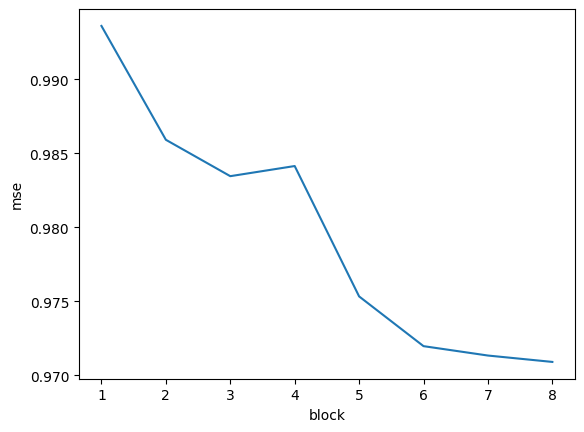

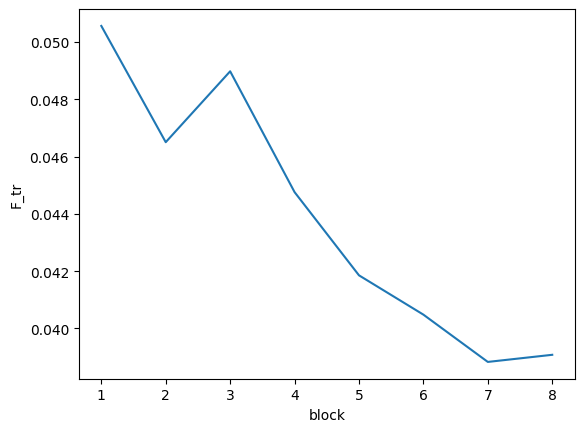

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')
if bttda.extra_train_info:
    n_samples = X.shape[0]
    sns.lineplot(data=df, x='block', y='mse')
    plt.show()
    #sns.lineplot(data=df,x='block',y='F_rt', hue='split')
    #plt.show()
    sns.lineplot(data=df,x='block',y='F_tr')

In [ ]:
fig, axs = plt.subplots(min(bttda.n_blocks_,8),3, figsize=(10,20))
for b in range(min(bttda.n_blocks_,8)):
    for k in range(3):
        scatter = bttda.blocks_[b].scatter_w_[k]
        scatter = tl.to_numpy(scatter)
        sns.heatmap(scatter, ax=axs[b,k], square=True, center=0, cmap='BrBG')

In [15]:
Xt = tl.to_numpy(bttda.transform(X))

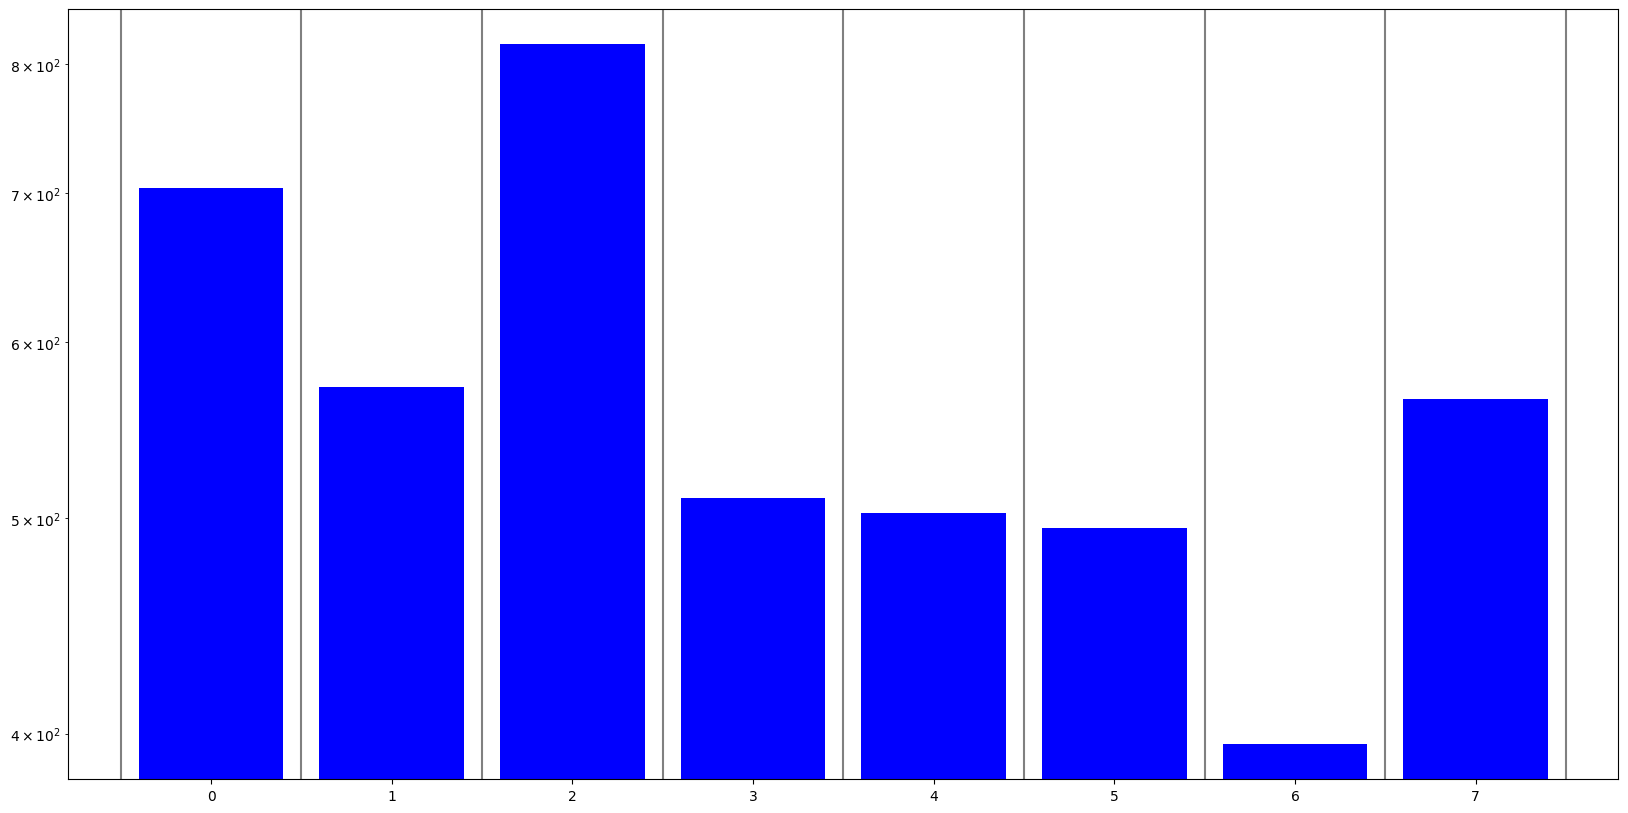

In [16]:
import scipy.stats
import seaborn as sns
import math
import numpy as np

samples = []
for c in bttda.blocks_[0].classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
F = F.flatten()
p = p.flatten()
p = np.nan_to_num(p, nan=1)

alpha=0.5
sig_idc = p < alpha

fig, ax = plt.subplots(1,1, figsize=(20,10))
ax.bar(np.arange(len(F))[sig_idc],F[sig_idc], color='blue')
ax.bar(np.arange(len(F))[~sig_idc],F[~sig_idc], color='red')
ax.set_yscale('log')
n_params=0
ax.axvline(n_params-.5, color='grey')
for b in bttda.blocks_:
    n_params+=math.prod(b.rank_)
    ax.axvline(n_params-.5, color='grey')


<Axes: >

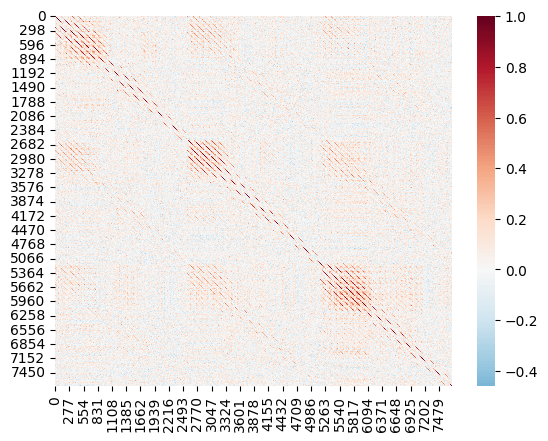

In [17]:
sns.heatmap(np.corrcoef(tl.to_numpy(X.reshape((n_samples, -1))), rowvar=False),  cmap='RdBu_r', center=0)

<Axes: >

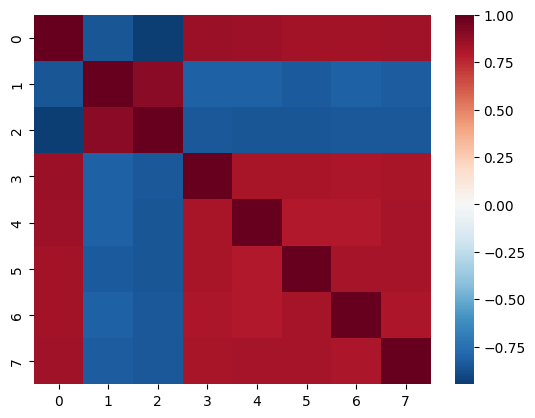

In [18]:
sns.heatmap(np.corrcoef(tl.to_numpy(Xt), rowvar=False),  cmap='RdBu_r', center=0)

In [19]:
from sklearn.decomposition import PCA
import seaborn as sns
from matplotlib import pyplot as plt

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(Xt_flat)
    df = pd.DataFrame(Xt_viz, columns=['PC1', 'PC2'])
    df['label'] = y
    df=df.reset_index()
    print(df)
    #sns.scatterplot(data=df, x='PC1', y='PC2', hue='label',)
    sns.kdeplot(data=df, x='PC1', y='PC2', hue='label',)
    ax = plt.gca()    
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

NameError: name 'Xt_flat' is not defined

In [ ]:
 import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]))
joint_args=dict(ts_args=ts_args)

In [ ]:
from mne import EvokedArray
for b in bttda.blocks_[:8]:
    means_rec = b.inv_transform(b.transform(b.means_))
    contrast = means_rec[1]-means_rec[0]
    contrast = EvokedArray(tl.to_numpy(contrast), epochs.info, epochs.tmin)
    contrast.plot_joint(**joint_args)